In [1]:
import pandas as  pd 
import matplotlib.pyplot as plt 
import numpy as np
from SFstarred.utils import plot_image_and_noisemap
from SFstarred.save_and_read import read_hdf5_to_dict

In [2]:
# a function that generates a model instance and initial guess parameters:
from starred.deconvolution.deconvolution import setup_model
# a parameters handler:
from starred.deconvolution.parameters import ParametersDeconv
# the loss function, basically chi² + regularization
from starred.deconvolution.loss import Loss
# the interface to the optimizer:
from starred.optim.optimization import Optimizer
# a way to propagate the noisemap through starlet layers:
from starred.utils.noise_utils import propagate_noise
# a plot utility to explore our deconvolution at every step
from starred.plots.plot_function import view_deconv_model

In [3]:
%load_ext autoreload
%autoreload 2

In [4]:
data_f160W = pd.read_pickle("data_for_starred/data_for_starred_F160_0214.pickle")

## Overview

This notebook applies the image-deconvolution procedure presented in the `start_here.ipynb` notebook from `starred`.

In [6]:

narrow_psfs = np.load('narrows_psfs/f160_narrow_psfs.npy')

if len(narrow_psfs.shape)==2:
	narrow_psfs = narrow_psfs[None,:]

In [ ]:
#"Weight map = 1 / sigma2"

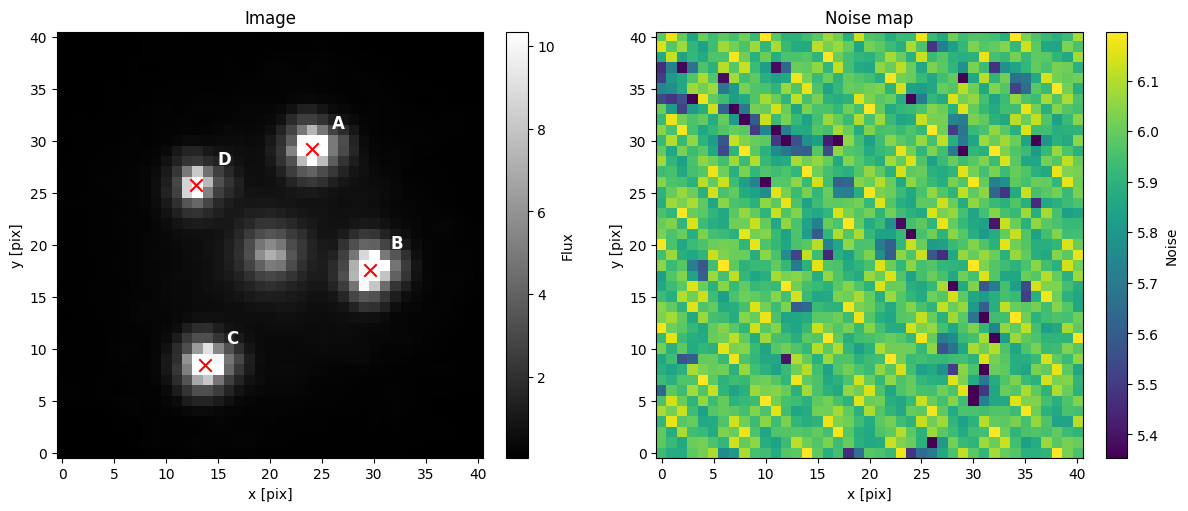

(1, 41, 41) (1, 41, 41)
[ 9.60743656  4.01177314 -6.20281186 -7.0881054 ]
[ -2.39260519   9.18362889 -11.53556347   5.7310841 ]


In [9]:
data = data_f160W["data"]#['data_cutout']
noisemaps = 1/np.sqrt(data_f160W['data_noisemaps'])#['sigma2']
image_positions = data_f160W["coord_pix_images"]
image_names = data_f160W["images_names"]
coord_pix_images_dict = data_f160W["coord_pix_images_dict"]
fig, ax = plot_image_and_noisemap(
    data=data[0],
    noisemaps=noisemaps[0],
    image_positions=image_positions,
    image_names=image_names,
    vmin=np.nanpercentile(data, 1),
    vmax=np.nanpercentile(data, 99),
    noise_vmin=np.nanpercentile(noisemaps, 1),
    noise_vmax=np.nanpercentile(noisemaps, 99),
)
plt.show()
im_size = data.shape[1]
offset = (im_size-1) / 2.
# while we're at it extract the x and y positions separately
xs = image_positions[:,0] - offset

ys = image_positions[:,1] - offset

# xs = np.array([coord_pix_images_dict[name][0] for name in 'ABCD']) - offset
# ys = np.array([coord_pix_images_dict[name][1] for name in 'ABCD']) - offset

brightnesses = len(data) * 4 * [np.max(data)]
print(data.shape,noisemaps.shape)
np.median(data[0]),np.median(noisemaps[0])
print(xs)
print(ys)

In [10]:
model, k_init, k_up, k_down, k_fixed = setup_model(data=data, 
                                                   sigma_2=noisemaps**2, 
                                                   s=narrow_psfs, 
                                                   xs=xs,
                                                   ys=ys,
                                                   initial_a=brightnesses,
                                                   subsampling_factor=2)

An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


In [11]:
k_fixed['kwargs_background']['h'] = k_init['kwargs_background']['h']

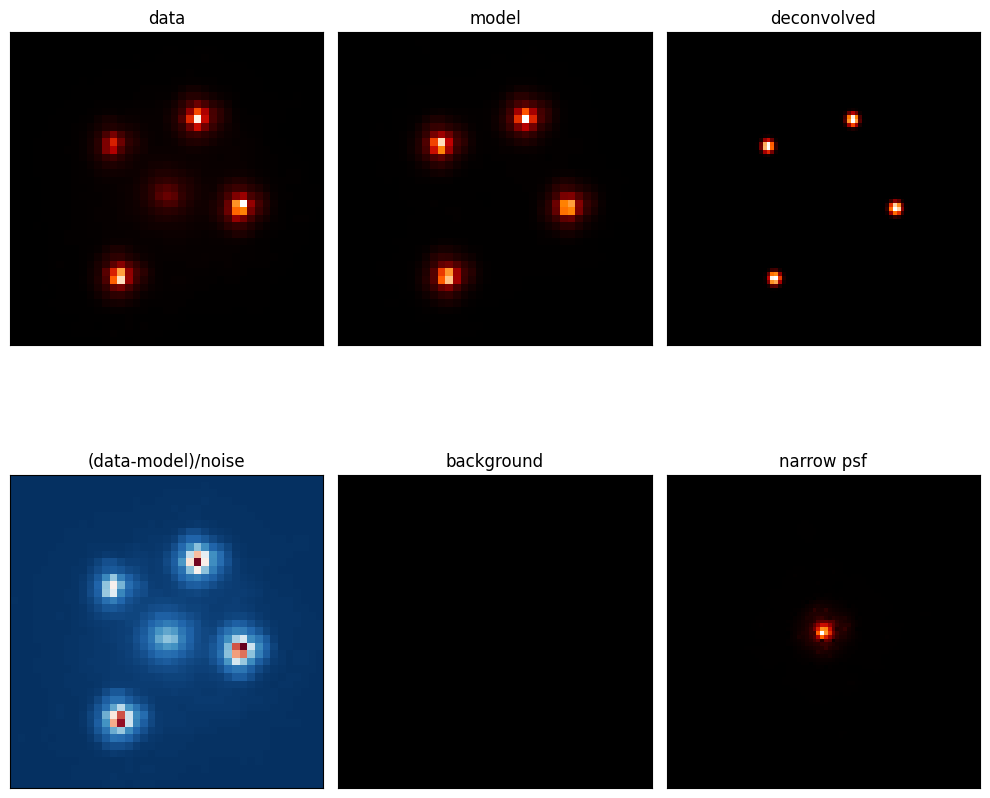

In [12]:
view_deconv_model(model, k_init, data, noisemaps**2, figsize=(10,10))

In [13]:
 # the params needs the initial guess, fixed params and boundaries:
params = ParametersDeconv(k_init, k_fixed, k_up, k_down)
# the loss needs to see our data, noisemaps, model, and the params class:
loss = Loss(data, model, params, noisemaps**2)
# now we can make an optimizer!
optim = Optimizer(loss, params, method='l-bfgs-b')

/home/felipe/miniconda3/envs/SFstarred/lib/python3.12/site-packages/starred/deconvolution/loss.py:149: UserWarning: lambda is not normalized. Provide the weight map !
  warnings.warn('lambda is not normalized. Provide the weight map !')


In [14]:
# optimize (this returns some metrics, but we don't need them here.)
optim.minimize(maxiter=70)
# the best fit is automatically given to the params:
k_optim = params.best_fit_values(as_kwargs=True)

In [15]:
k_optim

{'kwargs_analytic': {'a': Array([11.5003605, 10.347289 , 10.5471735,  6.3639374], dtype=float32),
  'c_x': Array([ 9.648267 ,  4.0190797, -6.1808033, -7.0647984], dtype=float32),
  'c_y': Array([ -2.3372197,   9.167264 , -11.532588 ,   5.7379937], dtype=float32),
  'dx': Array([0.], dtype=float32),
  'dy': Array([0.], dtype=float32),
  'alpha': Array([0.], dtype=float32)},
 'kwargs_background': {'mean': Array([1.3579115e-07], dtype=float32),
  'h': Array([0., 0., 0., ..., 0., 0., 0.], dtype=float32)},
 'kwargs_sersic': {'amp': Array([], shape=(0,), dtype=float32),
  'R_sersic': Array([], shape=(0,), dtype=float32),
  'n_sersic': Array([], shape=(0,), dtype=float32),
  'center_x': Array([], shape=(0,), dtype=float32),
  'center_y': Array([], shape=(0,), dtype=float32),
  'e1': Array([], shape=(0,), dtype=float32),
  'e2': Array([], shape=(0,), dtype=float32)}}

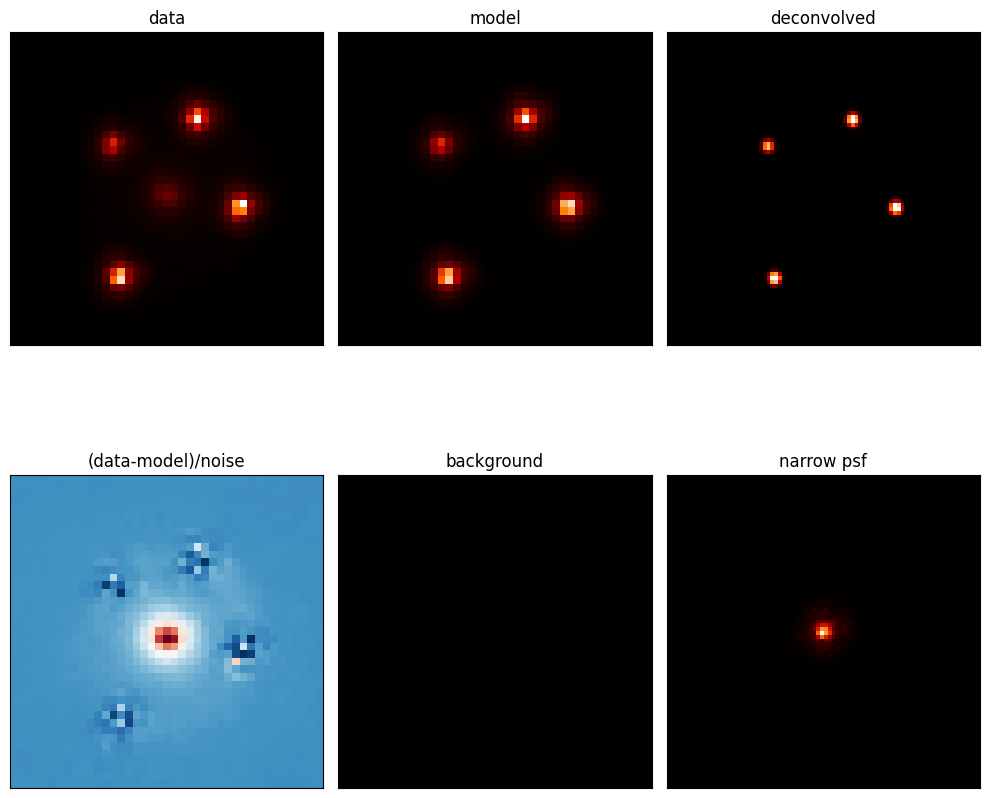

In [16]:
view_deconv_model(model, k_optim, data, noisemaps**2, figsize=(10,10))

In [17]:
 # remove the background fixing:
del k_fixed['kwargs_background']['h']
# calculate the propagation of the noise:
W = propagate_noise(model, noisemaps, k_init, upsampling_factor=2)[0]

In [18]:
# start from our optimized params of before
params = ParametersDeconv(k_optim, k_fixed, k_up, k_down)
# this time we provide the noise scaling to the loss
loss = Loss(data, model, params, noisemaps**2, W=W)
# new optimizer!
optim = Optimizer(loss, params, method='l-bfgs-b')
# let's go directly:
optim.minimize(maxiter=30)
k_optim_with_background = params.best_fit_values(as_kwargs=True).copy()

In [19]:
params.best_fit_values(as_kwargs=True)

{'kwargs_analytic': {'a': Array([11.189979,  9.98539 , 10.41358 ,  5.991218], dtype=float32),
  'c_x': Array([ 9.667156 ,  4.0179644, -6.190809 , -7.091331 ], dtype=float32),
  'c_y': Array([ -2.3186615,   9.17338  , -11.544146 ,   5.757973 ], dtype=float32),
  'dx': Array([0.], dtype=float32),
  'dy': Array([0.], dtype=float32),
  'alpha': Array([0.], dtype=float32)},
 'kwargs_background': {'mean': Array([0.05311855], dtype=float32),
  'h': Array([-0.08753406, -0.09175055, -0.08565136, ..., -0.09324332,
         -0.09293503, -0.0902323 ], dtype=float32)},
 'kwargs_sersic': {'amp': Array([], shape=(0,), dtype=float32),
  'R_sersic': Array([], shape=(0,), dtype=float32),
  'n_sersic': Array([], shape=(0,), dtype=float32),
  'center_x': Array([], shape=(0,), dtype=float32),
  'center_y': Array([], shape=(0,), dtype=float32),
  'e1': Array([], shape=(0,), dtype=float32),
  'e2': Array([], shape=(0,), dtype=float32)}}

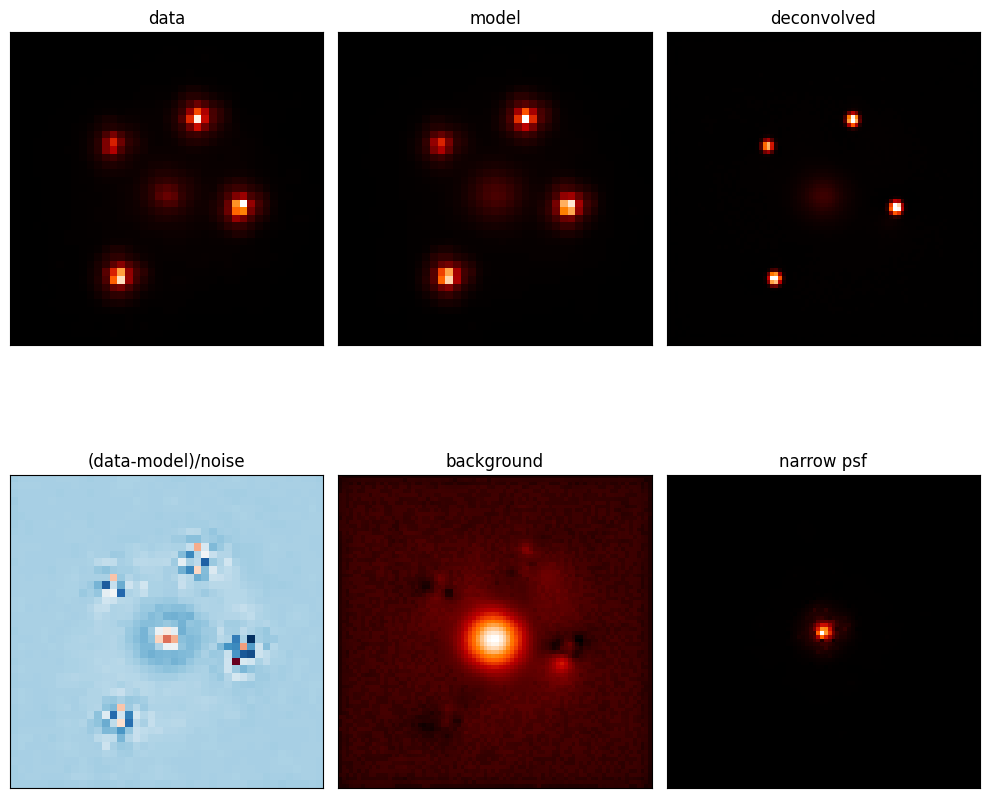

In [20]:
view_deconv_model(model, k_optim_with_background, data, noisemaps**2, figsize=(10,10))

{'kwargs_analytic': {'c_x': array([ 9.60743656,  4.01177314, -6.20281186, -7.0881054 ]), 'c_y': array([ -2.39260519,   9.18362889, -11.53556347,   5.7310841 ]), 'dx': array([0.]), 'dy': array([0.]), 'alpha': array([0.]), 'a': array([760.80782743, 760.80782743, 760.80782743, 760.80782743])}, 'kwargs_background': {'h': array([0., 0., 0., ..., 0., 0., 0.], shape=(6724,)), 'mean': array([0.])}, 'kwargs_sersic': {'amp': [], 'R_sersic': [], 'n_sersic': [], 'center_x': [], 'center_y': [], 'e1': [], 'e2': []}}


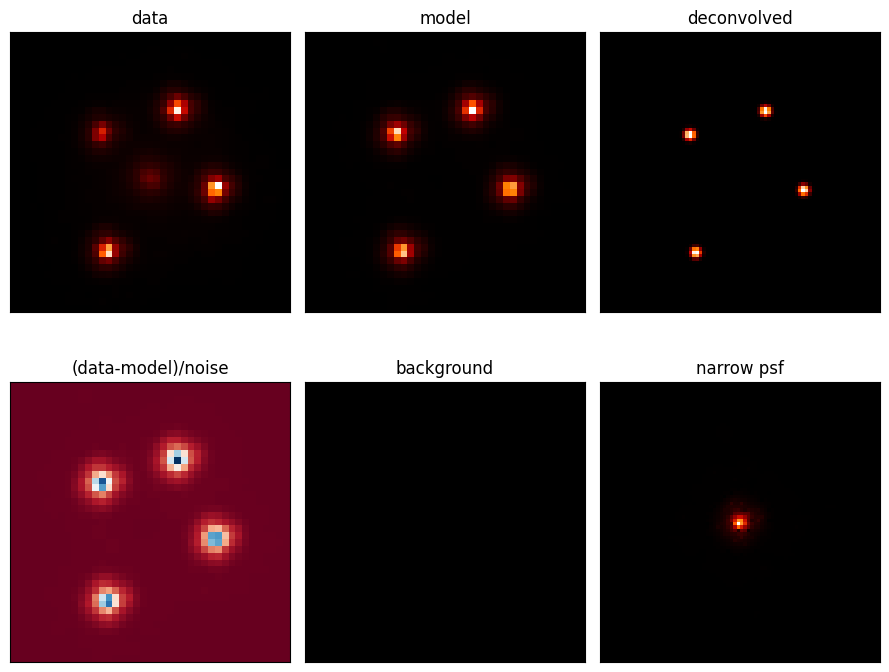

In [21]:
initial_c_x = xs
initial_c_y =ys

brightnesses = len(data) * 4 * [2e4]

model, kwargs_init, kwargs_up, kwargs_down, kwargs_fixed = setup_model(data, 
                                                                       noisemaps**2, 
                                                                       narrow_psfs, 
                                                                       initial_c_x,
                                                                       initial_c_y,
                                                                       2,
                                                                       initial_a = brightnesses,
                                                                       N_sersic = 0)


parameters = ParametersDeconv(kwargs_init, 
                              kwargs_fixed, 
                              kwargs_up=kwargs_up, 
                              kwargs_down=kwargs_down)

# print our initial parameters:
print(kwargs_init)
view_deconv_model(model, kwargs_init, data, noisemaps**2)

In [34]:
from copy import deepcopy
from pprint import pprint
from starred.procedures.deconvolution_routines import multi_steps_deconvolution
from starred.plots.plot_function import view_deconv_model, plot_loss, plot_deconvolution

Step 1, fixing : ['pts-source-astrometry', 'background']
Step 1/2 took  0 seconds
Kwargs partial at step 1/2 {'kwargs_analytic': {'a': Array([11.481175 , 10.345432 , 10.547565 ,  6.3656363], dtype=float32), 'c_x': Array([ 9.607436 ,  4.011773 , -6.2028117, -7.088105 ], dtype=float32), 'c_y': Array([ -2.3926053,   9.183629 , -11.535563 ,   5.731084 ], dtype=float32), 'dx': Array([0.], dtype=float32), 'dy': Array([0.], dtype=float32), 'alpha': Array([0.], dtype=float32)}, 'kwargs_background': {'mean': Array([0.], dtype=float32), 'h': Array([0., 0., 0., ..., 0., 0., 0.], dtype=float32)}, 'kwargs_sersic': {'amp': Array([], shape=(0,), dtype=float32), 'R_sersic': Array([], shape=(0,), dtype=float32), 'n_sersic': Array([], shape=(0,), dtype=float32), 'center_x': Array([], shape=(0,), dtype=float32), 'center_y': Array([], shape=(0,), dtype=float32), 'e1': Array([], shape=(0,), dtype=float32), 'e2': Array([], shape=(0,), dtype=float32)}}
Loss :  8.562547
Overall Reduced Chi2 :  0.010187444
Ste

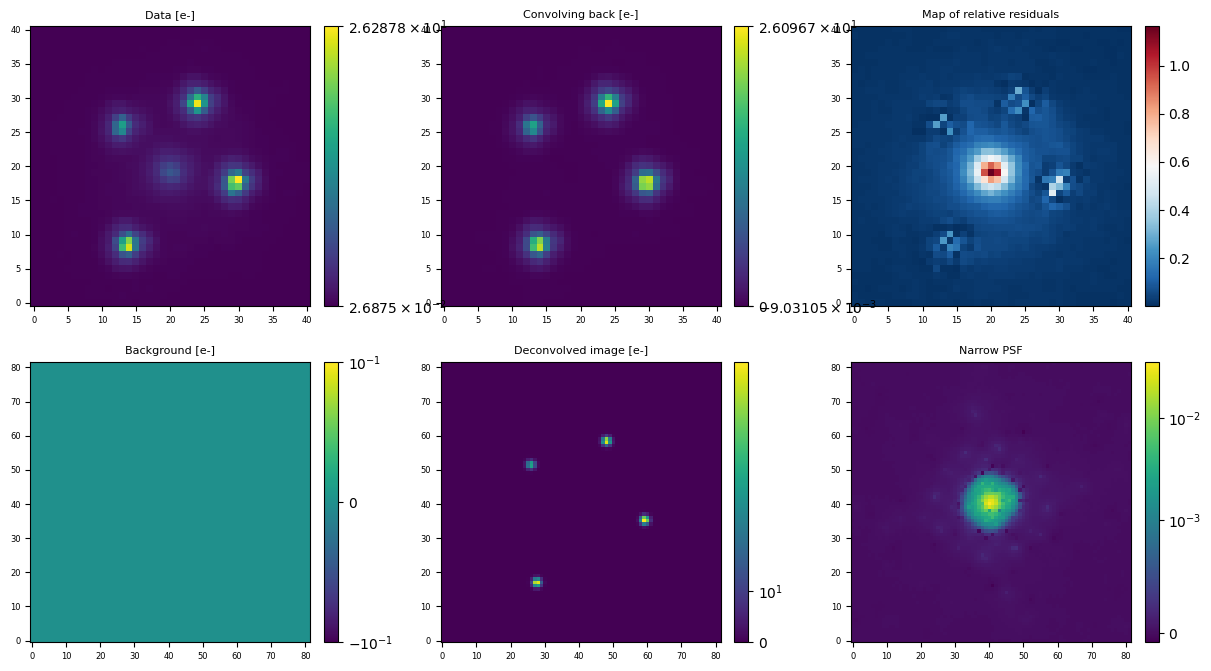

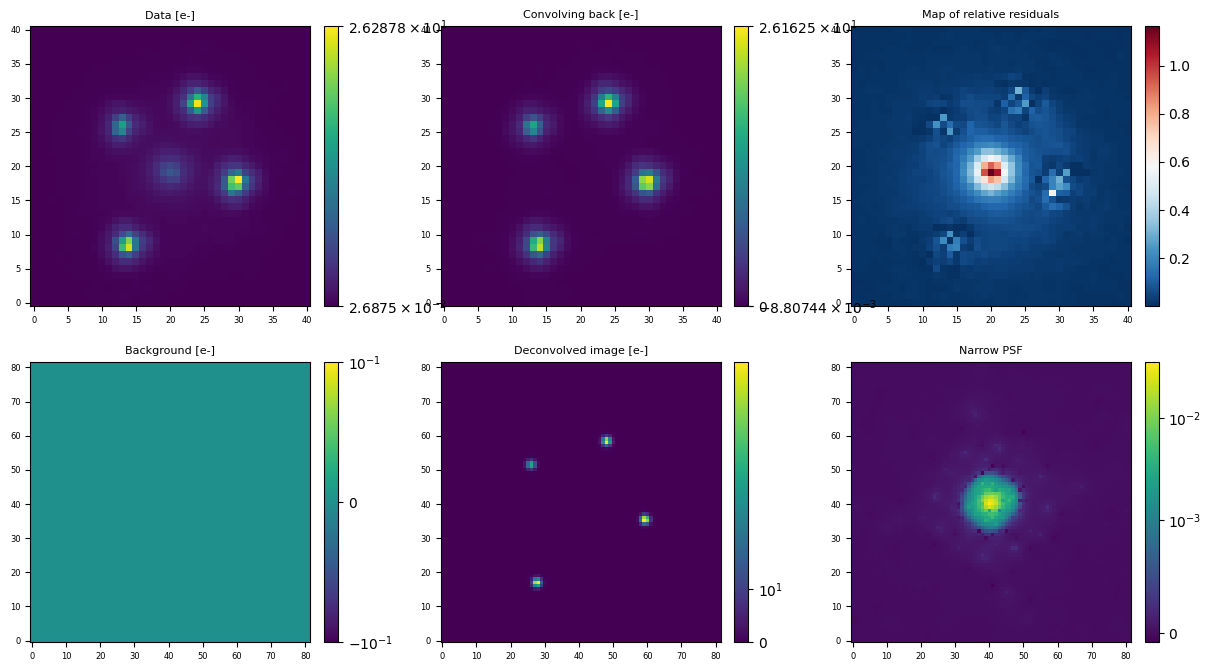

In [29]:
#Selecting the fixed components at each step, the rest is free. Format [['pts-source-astrometry','pts-source-photometry','background'],['pts-source-astrometry','pts-source-photometry'], ...]
fitting_sequence = [['pts-source-astrometry', 'background'], #step 1 : fix the astrometry and the pixelated background. Optimise the Sersic profile + photometry of the point sources
                    ['background'], #step 2: release astrometry, keep the pixelated background constant.
        ]
    
#Since we have no regularisation, we can use 'l-bfgs-b'. 
optim_list = ['l-bfgs-b','l-bfgs-b']

#l-fgs-b, you can use the following parameters: 
kwargs_lbfgs = {'maxiter':50}

#list of configuration for the optimsers 
kwargs_optim_list = [kwargs_lbfgs, kwargs_lbfgs] 

#we apply our astrometric prior nonly when the point sources are free (i.e. not for the second step)
prior_list=[None,None]

model, parameters, loss, kwargs_partial_list, fig_list, LogL_list, loss_history_list = multi_steps_deconvolution(data, model, parameters, noisemaps**2, narrow_psfs, 2,
                                                                                    fitting_sequence = fitting_sequence,
                                                                                    optim_list = optim_list, kwargs_optim_list = kwargs_optim_list,
                                                                                    #lambda_scales = 0, lambda_hf =0, 
                                                                                    lambda_positivity_ps=100, #we don't want the poitn source to be negative
                                                                                    prior_list = prior_list,
                                                                                    adjust_sky = False, #Sky has already been subtracted
                                                                                    noise_propagation = 'MC')

{'kwargs_analytic': {'a': Array([11.506456 , 10.346789 , 10.548316 ,  6.3667455], dtype=float32),
                     'alpha': Array([0.], dtype=float32),
                     'c_x': Array([ 9.648732 ,  4.019903 , -6.1811085, -7.065463 ], dtype=float32),
                     'c_y': Array([ -2.33819 ,   9.167501, -11.53279 ,   5.740471], dtype=float32),
                     'dx': Array([0.], dtype=float32),
                     'dy': Array([0.], dtype=float32)},
 'kwargs_background': {'h': Array([0., 0., 0., ..., 0., 0., 0.], dtype=float32),
                       'mean': Array([0.], dtype=float32)},
 'kwargs_sersic': {'R_sersic': Array([], shape=(0,), dtype=float32),
                   'amp': Array([], shape=(0,), dtype=float32),
                   'center_x': Array([], shape=(0,), dtype=float32),
                   'center_y': Array([], shape=(0,), dtype=float32),
                   'e1': Array([], shape=(0,), dtype=float32),
                   'e2': Array([], shape=(0,), dtype=float

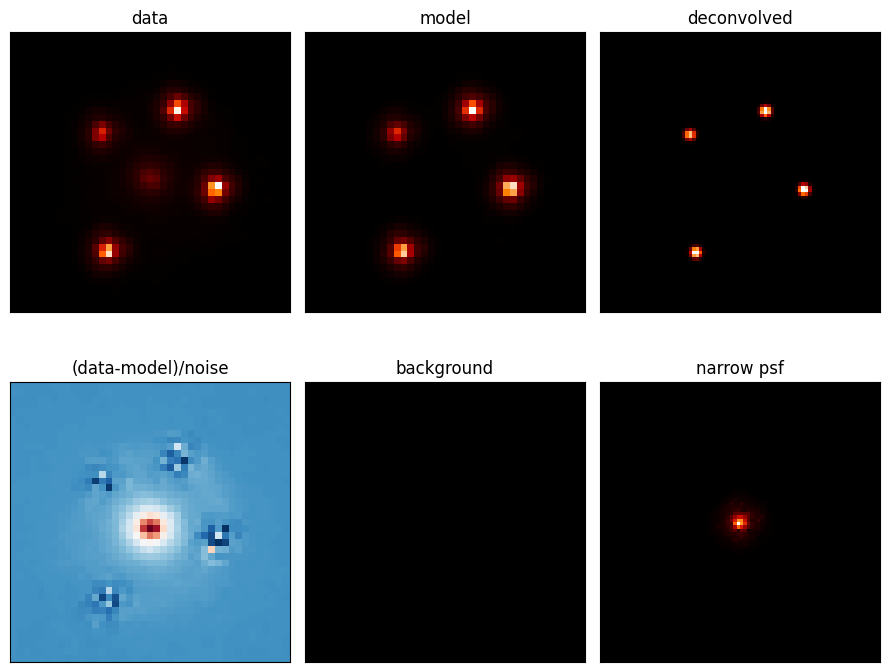

In [30]:
# Printing and visualizing the partial results
kwargs_partial = deepcopy(parameters.best_fit_values(as_kwargs=True))
pprint(kwargs_partial)
view_deconv_model(model, kwargs_partial, data,  noisemaps**2)

Step 1, fixing : []


optax.adabelief: 100%|██████████| 500/500 [00:11<00:00, 43.09it/s]


Step 1/2 took 12 seconds
Kwargs partial at step 1/2 {'kwargs_analytic': {'a': Array([11.139146 , 10.014802 , 10.240292 ,  6.0180054], dtype=float32), 'c_x': Array([ 9.654291 ,  4.0220847, -6.1820097, -7.072905 ], dtype=float32), 'c_y': Array([ -2.3390558,   9.171571 , -11.535641 ,   5.7476344], dtype=float32), 'dx': Array([0.], dtype=float32), 'dy': Array([0.], dtype=float32), 'alpha': Array([0.], dtype=float32)}, 'kwargs_background': {'mean': Array([-0.30978552], dtype=float32), 'h': Array([0.30877063, 0.3088382 , 0.31306493, ..., 0.3114752 , 0.31234327,
       0.3123322 ], dtype=float32)}, 'kwargs_sersic': {'amp': Array([], shape=(0,), dtype=float32), 'R_sersic': Array([], shape=(0,), dtype=float32), 'n_sersic': Array([], shape=(0,), dtype=float32), 'center_x': Array([], shape=(0,), dtype=float32), 'center_y': Array([], shape=(0,), dtype=float32), 'e1': Array([], shape=(0,), dtype=float32), 'e2': Array([], shape=(0,), dtype=float32)}}
Loss :  14.049352
Overall Reduced Chi2 :  0.00496

optax.adabelief: 100%|██████████| 500/500 [00:10<00:00, 46.82it/s]


Step 2/2 took 11 seconds
Kwargs partial at step 2/2 {'kwargs_analytic': {'a': Array([11.023383,  9.950072, 10.23053 ,  5.922575], dtype=float32), 'c_x': Array([ 9.654291 ,  4.0220847, -6.1820097, -7.072905 ], dtype=float32), 'c_y': Array([ -2.3390558,   9.171571 , -11.535641 ,   5.7476344], dtype=float32), 'dx': Array([0.], dtype=float32), 'dy': Array([0.], dtype=float32), 'alpha': Array([0.], dtype=float32)}, 'kwargs_background': {'mean': Array([-0.30019718], dtype=float32), 'h': Array([0.30758938, 0.30261564, 0.3057611 , ..., 0.30411297, 0.3007455 ,
       0.29917395], dtype=float32)}, 'kwargs_sersic': {'amp': Array([], shape=(0,), dtype=float32), 'R_sersic': Array([], shape=(0,), dtype=float32), 'n_sersic': Array([], shape=(0,), dtype=float32), 'center_x': Array([], shape=(0,), dtype=float32), 'center_y': Array([], shape=(0,), dtype=float32), 'e1': Array([], shape=(0,), dtype=float32), 'e2': Array([], shape=(0,), dtype=float32)}}
Loss :  13.248426
Overall Reduced Chi2 :  0.004165503

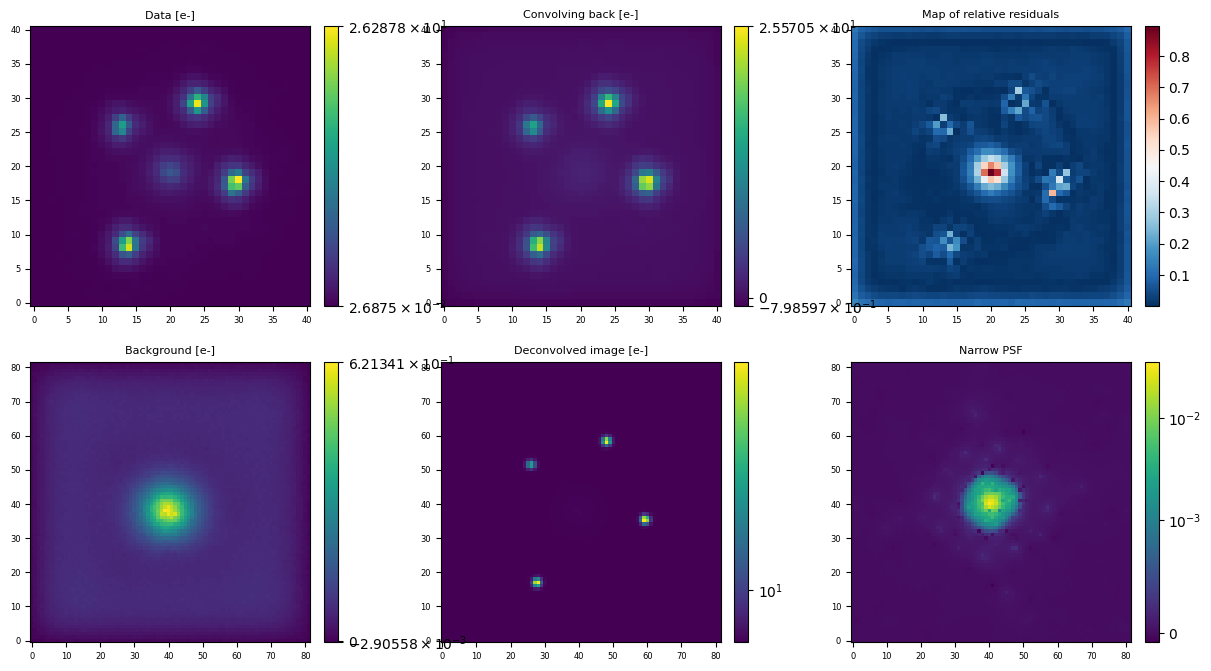

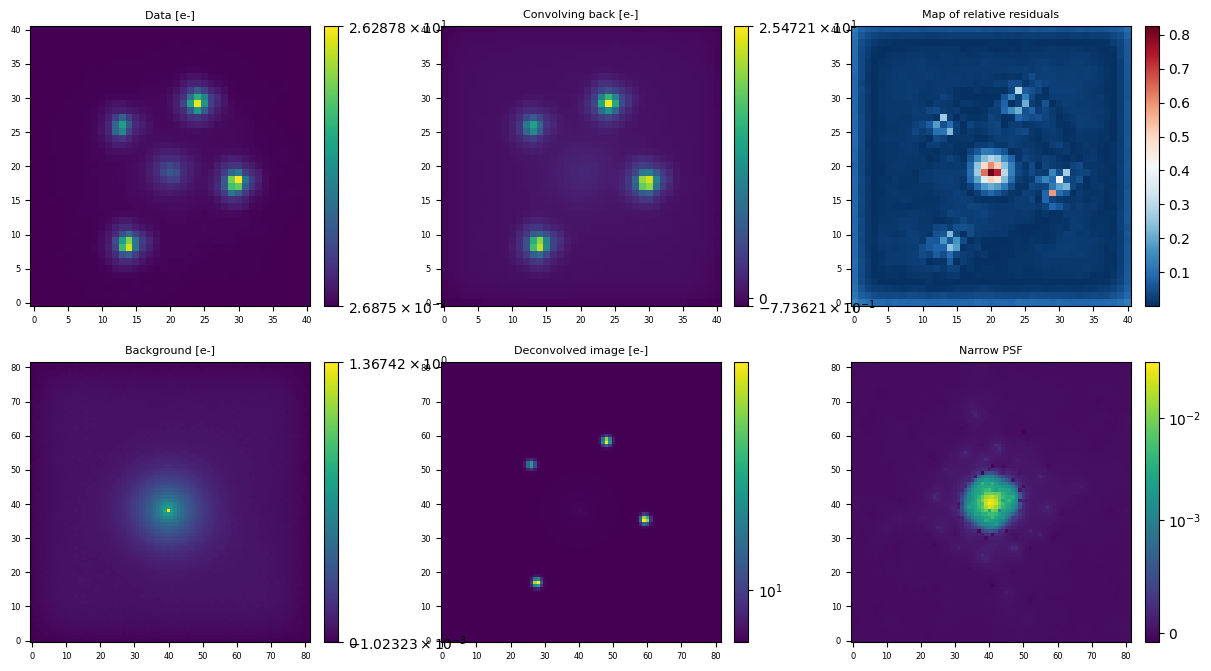

In [32]:
#Selecting the fixed components at each step, the rest is free. Format [['pts-source-astrometry','pts-source-photometry','background'],['pts-source-astrometry','pts-source-photometry'], ...]
fitting_sequence = [[], #step 1 : fix the Sersic profile and the astrometry, release the background
                    ['pts-source-astrometry']
                    #['background'],
        ]
    
optim_list = ['adabelief','adabelief']
kwargs_optax1 = {'max_iterations': 500, 'min_iterations': None,
        'init_learning_rate': 5e-2, 'schedule_learning_rate': True,
        'restart_from_init': False, 'stop_at_loss_increase': False,
        'progress_bar': True, 'return_param_history': True
    }
kwargs_optax2 = {
        'max_iterations': 500, 'min_iterations': None,
        'init_learning_rate': 1e-2, 'schedule_learning_rate': True,
        'restart_from_init': False, 'stop_at_loss_increase': False,
        'progress_bar': True, 'return_param_history': True
    }
kwargs_optim_list = [kwargs_optax1, kwargs_optax2] 
prior_list=[None,None]

parameters = ParametersDeconv(kwargs_partial, 
                              kwargs_fixed, 
                              kwargs_up=kwargs_up, 
                              kwargs_down=kwargs_down)

model, parameters, loss, kwargs_partial_list, fig_list, LogL_list, loss_history_list = multi_steps_deconvolution(data, model, parameters,  noisemaps**2, narrow_psfs, 2,
                                                                                    fitting_sequence = fitting_sequence,
                                                                                    optim_list = optim_list, kwargs_optim_list = kwargs_optim_list,
                                                                                    #lambda_scales = 1, lambda_hf =lambda_hf, 
                                                                                    lambda_positivity_ps=100, #we don't want the poitn source to be negative
                                                                                    prior_list = prior_list,
                                                                                    adjust_sky = True, #Sky has already been subtracted
                                                                                    noise_propagation = 'MC')

Step 1, optimiser adabelief
Step 2, optimiser adabelief
{'kwargs_analytic': {'a': Array([11.023383,  9.950072, 10.23053 ,  5.922575], dtype=float32), 'c_x': Array([ 9.654291 ,  4.0220847, -6.1820097, -7.072905 ], dtype=float32), 'c_y': Array([ -2.3390558,   9.171571 , -11.535641 ,   5.7476344], dtype=float32), 'dx': Array([0.], dtype=float32), 'dy': Array([0.], dtype=float32), 'alpha': Array([0.], dtype=float32)}, 'kwargs_background': {'mean': Array([-0.30019718], dtype=float32), 'h': Array([0.30758938, 0.30261564, 0.3057611 , ..., 0.30411297, 0.3007455 ,
       0.29917395], dtype=float32)}, 'kwargs_sersic': {'amp': Array([], shape=(0,), dtype=float32), 'R_sersic': Array([], shape=(0,), dtype=float32), 'n_sersic': Array([], shape=(0,), dtype=float32), 'center_x': Array([], shape=(0,), dtype=float32), 'center_y': Array([], shape=(0,), dtype=float32), 'e1': Array([], shape=(0,), dtype=float32), 'e2': Array([], shape=(0,), dtype=float32)}}
Overall Reduced Chi2 :  0.004165503


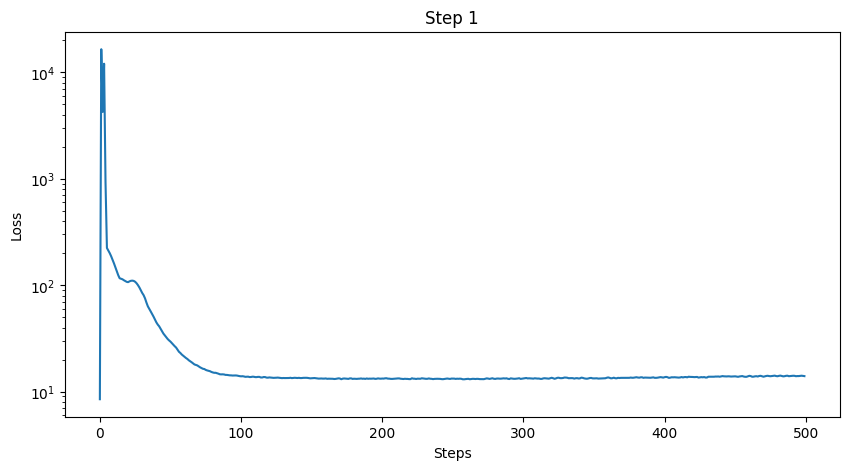

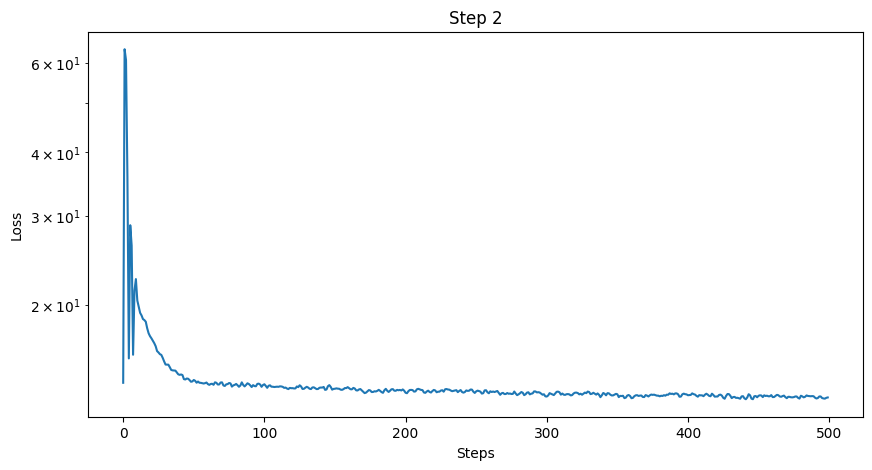

In [35]:
for i in range(len(loss_history_list)):
    print('Step %i, optimiser %s'%(i+1, optim_list[i]))
    plot_loss(loss_history=loss_history_list[i], title = 'Step %i'%(i+1))

kwargs_final = deepcopy(parameters.best_fit_values(as_kwargs=True))
print(kwargs_final)
print('Overall Reduced Chi2 : ', loss.reduced_chi2(kwargs_final))

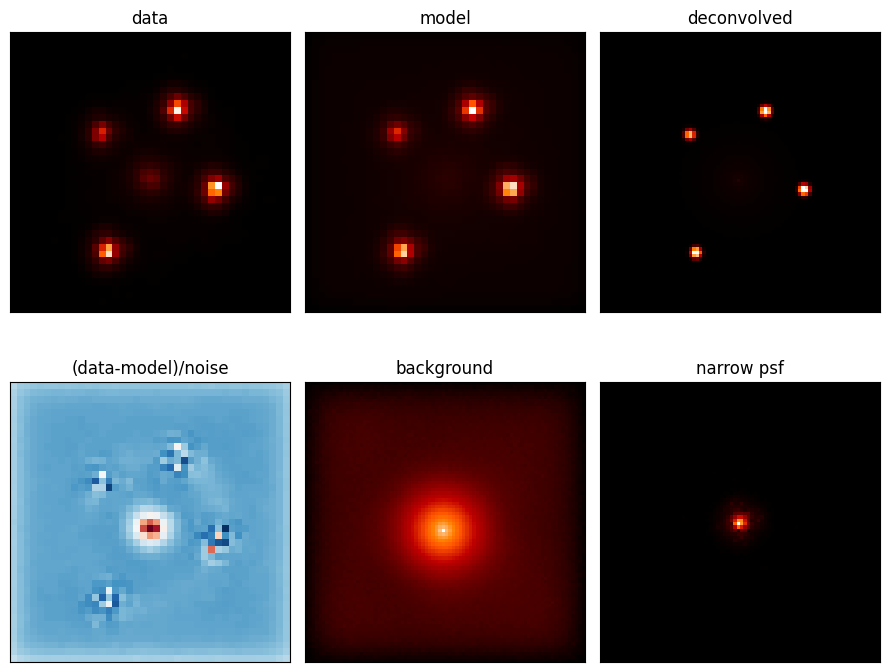

In [36]:
view_deconv_model(model, kwargs_final, data,  noisemaps**2)